In [48]:
#Import library
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
%matplotlib inline
import warnings
warnings.filterwarnings('ignore')

### Read the input file 'Diabetes.csv' using Pandas and check it's column names(1 Marks)

In [49]:
df = pd.read_csv("Diabetes.csv")

In [50]:
list(df.columns) 

['Pregnancies',
 'Glucose',
 'BloodPressure',
 'SkinThickness',
 'Insulin',
 'BMI',
 'DiabetesPedigreeFunction',
 'Age',
 'Outcome']

In [51]:
# Eye ball the imported dataset

In [52]:
df.head(10)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
5,5,116,74,0,0,25.6,0.201,30,0
6,3,78,50,32,88,31.0,0.248,26,1
7,10,115,0,0,0,35.3,0.134,29,0
8,2,197,70,45,543,30.5,0.158,53,1
9,8,125,96,0,0,0.0,0.232,54,1


In [53]:
df.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

### Check dimension of dataset

In [54]:
df.shape

(768, 9)

### Check distribution of dependent variable, Outcome and plot it (1 Marks)

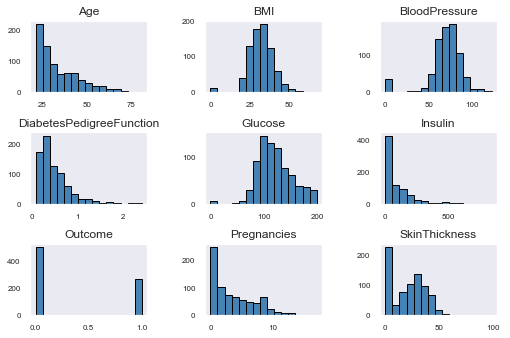

In [55]:
df.hist(bins=15, color='steelblue', edgecolor='black', linewidth=1.0,
           xlabelsize=8, ylabelsize=8, grid=False)    
plt.tight_layout(rect=(0, 0, 1.2, 1.2)) 

#Age, Diabetes Pedigree and Insulin features are right skewed.
#BMI, BloodPressure and Skin Thickness are eveny distributed with few outliers.
#Glucose feature is slightly right skewed.

In [56]:
df.Outcome.value_counts()

0    500
1    268
Name: Outcome, dtype: int64

#Out of  768 data points, 500 are labeled as 0 and 268 as 1.
#Outcome 0 means No diabetes, outcome 1 means diabetes

In [57]:
# Check data types and info of dataset

In [58]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
Pregnancies                 768 non-null int64
Glucose                     768 non-null int64
BloodPressure               768 non-null int64
SkinThickness               768 non-null int64
Insulin                     768 non-null int64
BMI                         768 non-null float64
DiabetesPedigreeFunction    768 non-null float64
Age                         768 non-null int64
Outcome                     768 non-null int64
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


### Check data distribution using summary statistics and provide your findings(2 Marks)

In [59]:
df.describe().transpose()

,count,mean,std,min,25%,50%,75%,max
Pregnancies,768.0,3.845052,3.369578,0.000,1.00000,3.0000,6.00000,17.00
Glucose,768.0,120.894531,31.972618,0.000,99.00000,117.0000,140.25000,199.00
BloodPressure,768.0,69.105469,19.355807,0.000,62.00000,72.0000,80.00000,122.00
SkinThickness,768.0,20.536458,15.952218,0.000,0.00000,23.0000,32.00000,99.00
Insulin,768.0,79.799479,115.244002,0.000,0.00000,30.5000,127.25000,846.00
BMI,768.0,31.992578,7.884160,0.000,27.30000,32.0000,36.60000,67.10
DiabetesPedigreeFunction,768.0,0.471876,0.331329,0.078,0.24375,0.3725,0.62625,2.42
Age,768.0,33.240885,11.760232,21.000,24.00000,29.0000,41.00000,81.00
Outcome,768.0,0.348958,0.476951,0.000,0.00000,0.0000,1.00000,1.00


#The spred of the data is more forGlucose, BloodPreassure, Skin Thickness and Age
#The Spread is very high for Insulin.
#Most of the data lies in the 3rd quartile.

### Do correlation analysis and bivariate viualization with Insights(1 Marks)

In [60]:
corr=df.corr()
corr

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
Pregnancies,1.000000,0.129459,0.141282,-0.081672,-0.073535,0.017683,-0.033523,0.544341,0.221898
Glucose,0.129459,1.000000,0.152590,0.057328,0.331357,0.221071,0.137337,0.263514,0.466581
BloodPressure,0.141282,0.152590,1.000000,0.207371,0.088933,0.281805,0.041265,0.239528,0.065068
SkinThickness,-0.081672,0.057328,0.207371,1.000000,0.436783,0.392573,0.183928,-0.113970,0.074752
Insulin,-0.073535,0.331357,0.088933,0.436783,1.000000,0.197859,0.185071,-0.042163,0.130548
BMI,0.017683,0.221071,0.281805,0.392573,0.197859,1.000000,0.140647,0.036242,0.292695
DiabetesPedigreeFunction,-0.033523,0.137337,0.041265,0.183928,0.185071,0.140647,1.000000,0.033561,0.173844
Age,0.544341,0.263514,0.239528,-0.113970,-0.042163,0.036242,0.033561,1.000000,0.238356
Outcome,0.221898,0.466581,0.065068,0.074752,0.130548,0.292695,0.173844,0.238356,1.000000


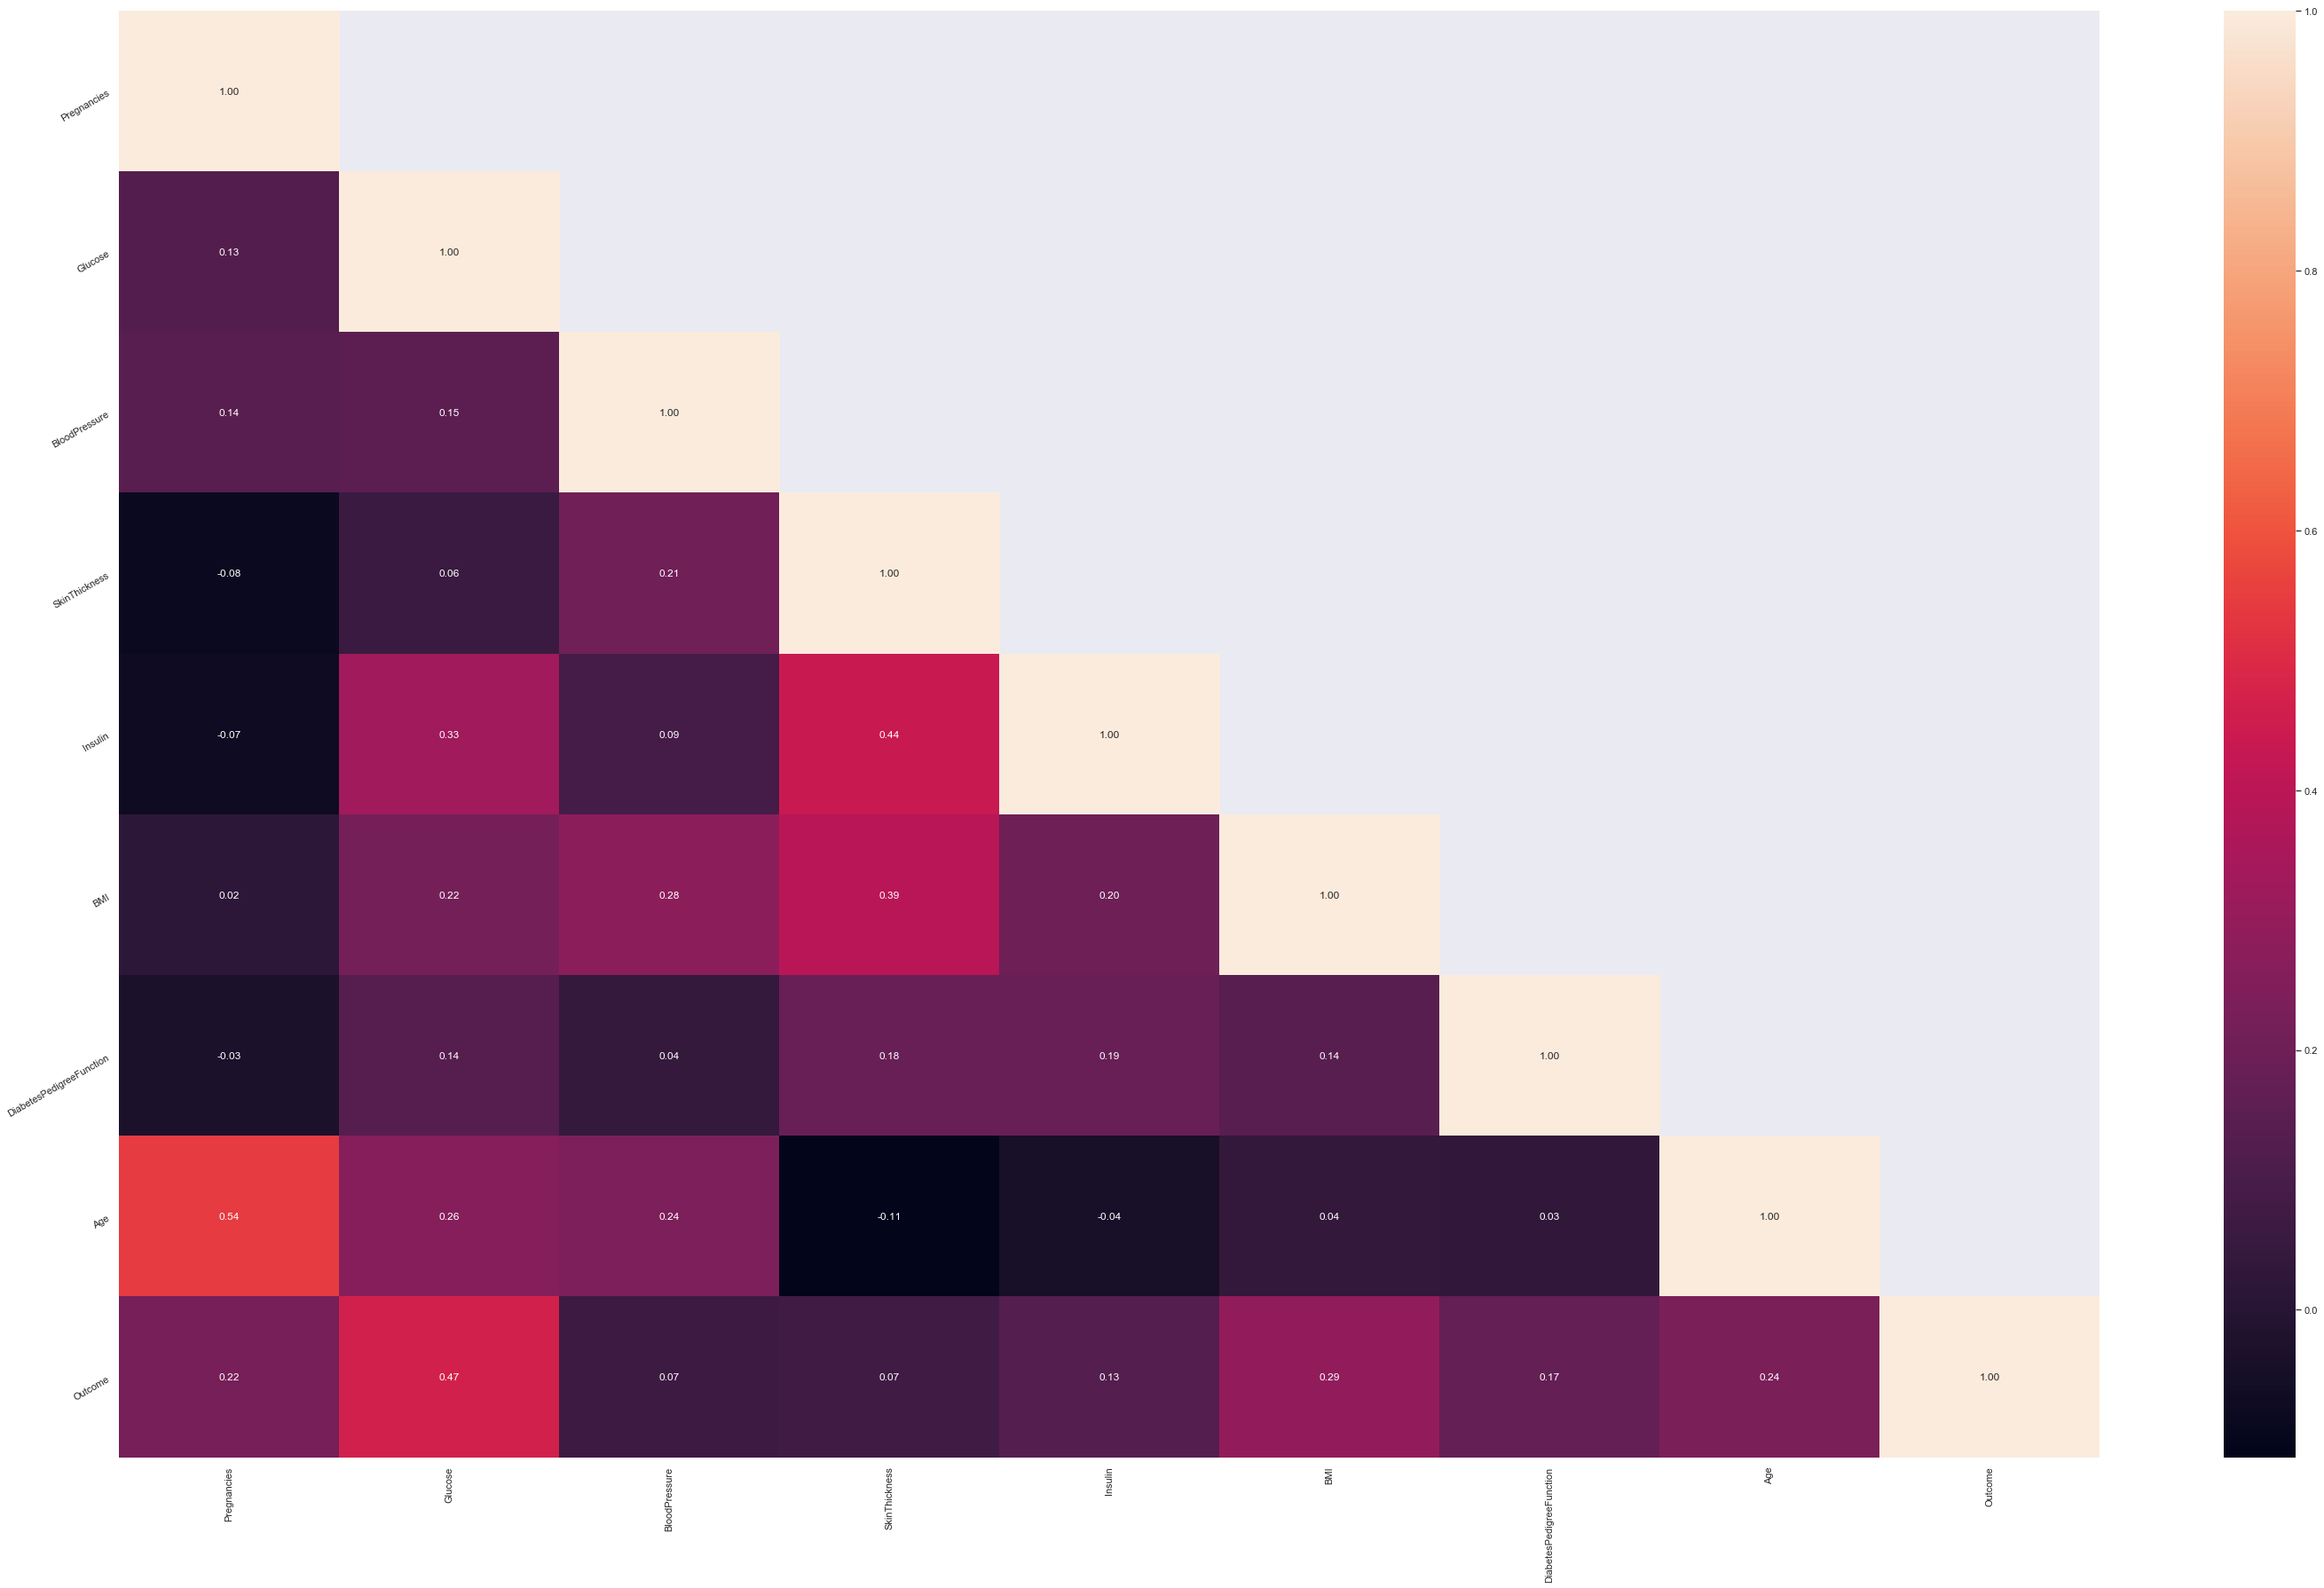

In [61]:
sns.set_context("notebook", font_scale=1.0, rc={"lines.linewidth": 3.5})
plt.figure(figsize=(50,30))
# create a mask so we only see the correlation values once
mask = np.zeros_like(corr)
mask[np.triu_indices_from(mask, 1)] = True
a = sns.heatmap(corr,mask=mask, annot=True, fmt='.2f')
rotx = a.set_xticklabels(a.get_xticklabels(), rotation=90)
roty = a.set_yticklabels(a.get_yticklabels(), rotation=30)

#There is no strong corelation between any of the features, so no need to remove any of the fetures as pre processing

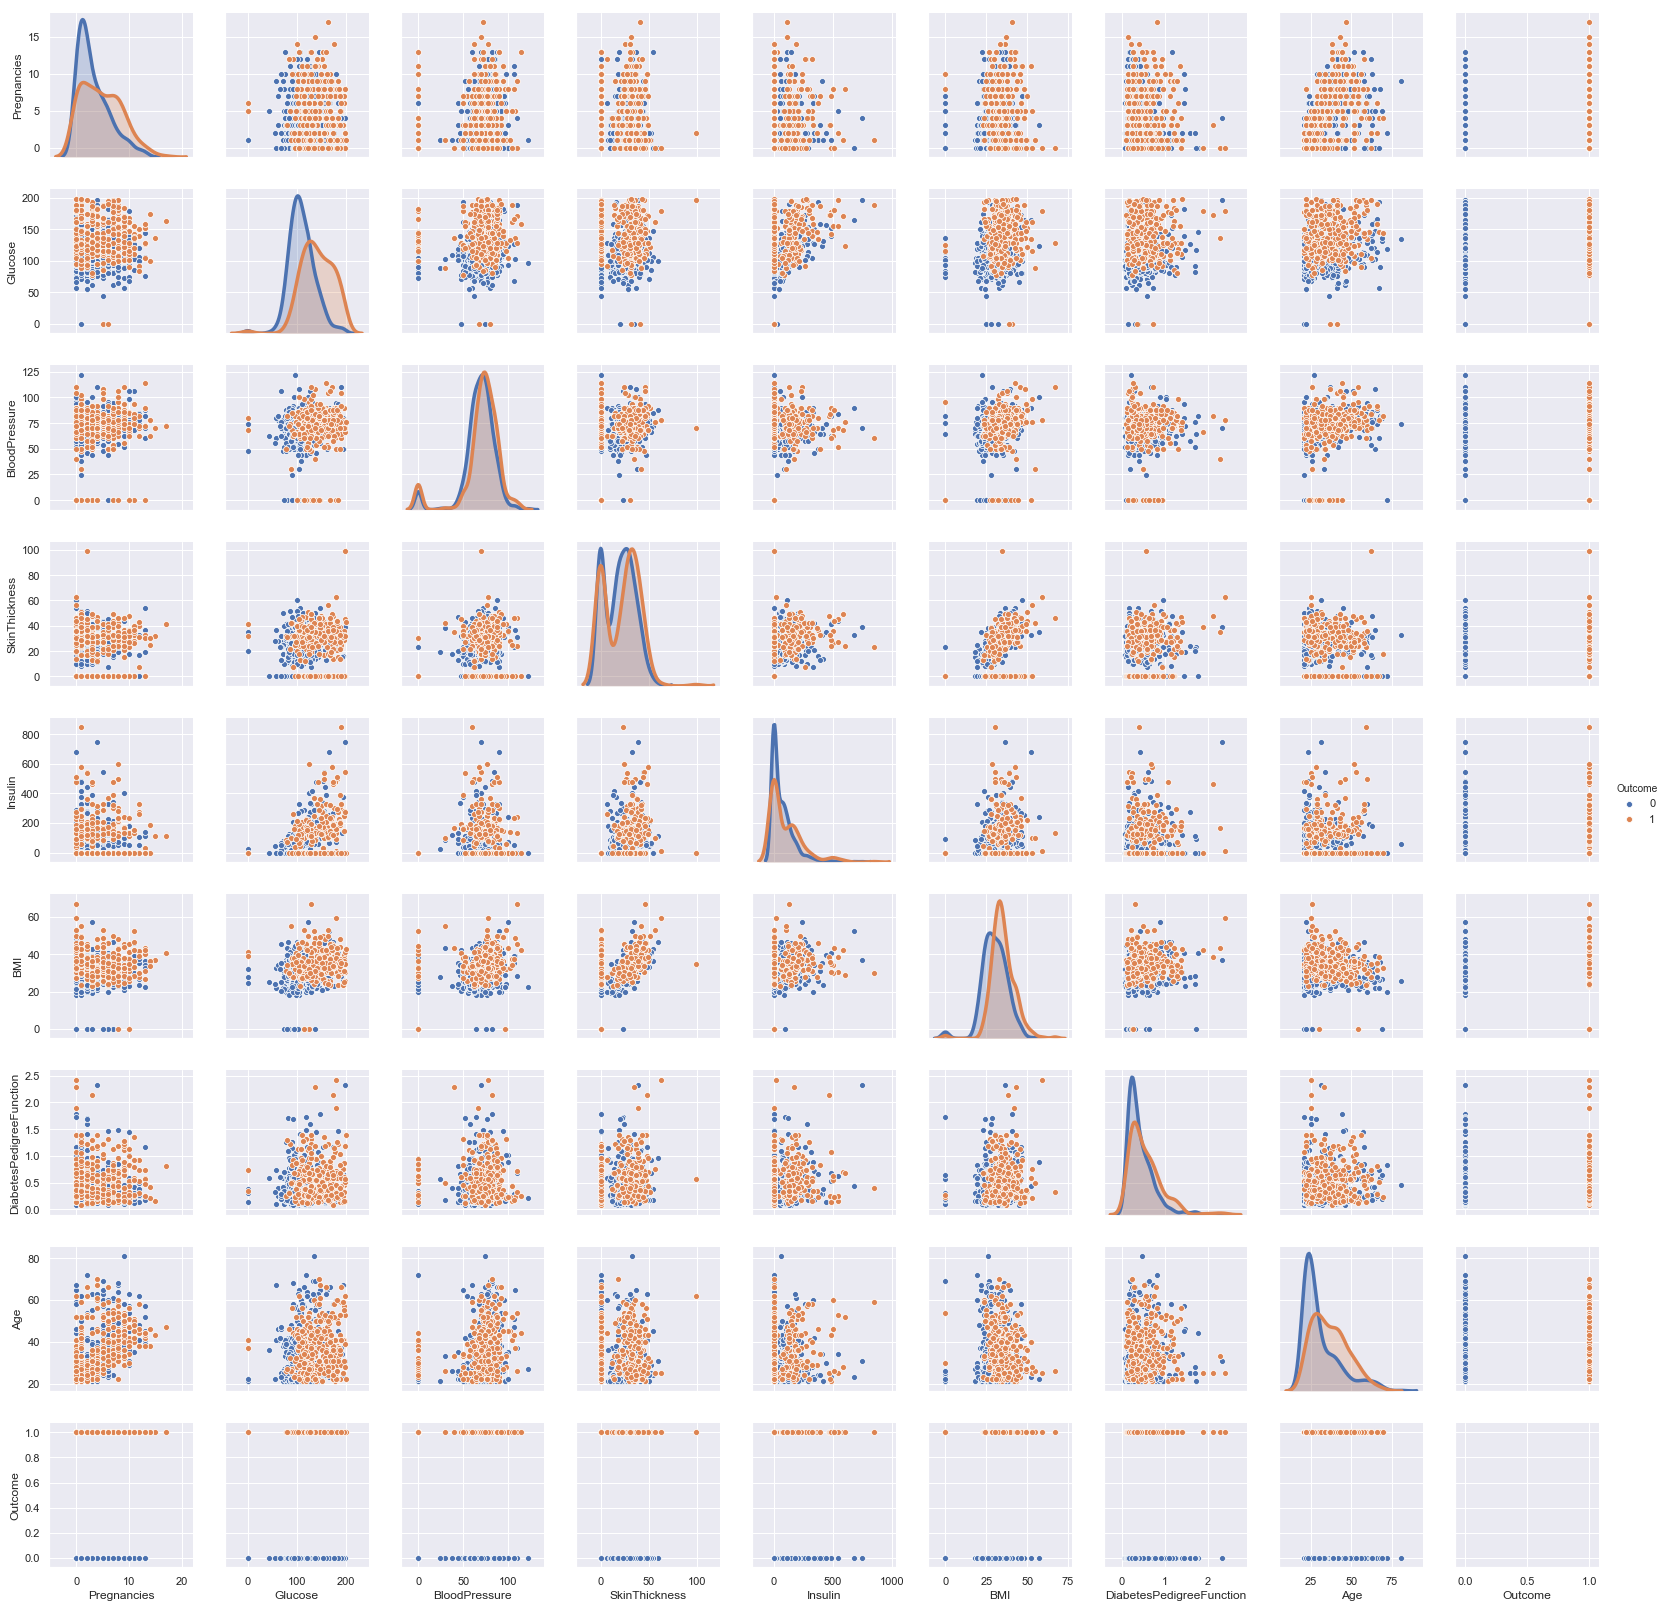

In [62]:
sns.pairplot(df, diag_kind = "kde", hue = "Outcome")

#### Do train and test split with stratify sampling on Outcome variable to maintain the distribution of dependent variable(1 Marks)

In [63]:
X = df.drop("Outcome", axis=1)
y = df["Outcome"]
test_size = 0.30 # taking 70:30 training and test set
seed = 7  # Random numbmer seeding for reapeatability of the code
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_size, random_state=seed, stratify=y)
print(X_train.shape)
print(X_test.shape)

(537, 8)
(231, 8)


### Train Support Vector Machine Model(1 Marks)

In [64]:
svc_model = SVC(C= .2, kernel='linear', gamma= 1)

In [65]:
svc_model.fit(X_train, y_train)
print(svc_model.score(X_train, y_train))

0.7802607076350093


In [66]:
print(svc_model.score(X_test, y_test))

0.7619047619047619


In [67]:
y_pred = svc_model.predict(X_test)
print("Confusion Matrix:\n",confusion_matrix(y_pred,y_test))

Confusion Matrix:
 [[132  37]
 [ 18  44]]


In [68]:
acc=accuracy_score(y_test,y_pred)
print(acc)

0.7619047619047619


#Though the model score for train dataset is 76, for test dataset the model score is very low

### Scale the data points using MinMaxScaler ( 1 Marks)

In [69]:
scaler = MinMaxScaler()

In [70]:
X_train_scl = scaler.fit_transform(X_train)

### Fit SVM Model on Scale data and give your observation( 1 Marks)

In [77]:
svc_model1 = SVC(C= .2, kernel='linear', gamma= 1)

In [78]:
svc_model1.fit(X_train_scl, y_train)
print(svc_model1.score(X_test, y_test))

0.35064935064935066


In [79]:
y_pred1 = svc_model1.predict(X_test)
print("Confusion Matrix:\n",confusion_matrix(y_pred1,y_test))

Confusion Matrix:
 [[  0   0]
 [150  81]]


In [80]:
acc=accuracy_score(y_test,y_pred1)
print(acc)

0.35064935064935066


Scaling the data did not help us in improving  performance of the model

#we can try increasing either C or gamma to fit a more complex model.

### Try improving the model accuracy using C=1000 (1 Marks)

In [86]:
svc_model2 = SVC(C= 1000, kernel='linear', gamma= 1)
svc_model2.fit(X_train_scl, y_train)

print(svc_model2.score(X_train, y_train))

0.34823091247672255


In [83]:
print(svc_model2.score(X_test, y_test))

0.3593073593073593


In [84]:
y_pred2 = svc_model2.predict(X_test)
print("Confusion Matrix:\n",confusion_matrix(y_pred2,y_test))

Confusion Matrix:
 [[  2   0]
 [148  81]]


In [85]:
acc=accuracy_score(y_test,y_pred2)
print(acc)

0.3593073593073593


Increasing C did not improve the model accuracy much.

### Let's try to explore different Kernel and C (Bonus for practice)

In [19]:
import multiprocessing 
from sklearn.model_selection import GridSearchCV

In [20]:
 param_grid = [    {        
     'kernel': ['linear', 'rbf', 'poly', 'sigmoid'],        
     'C': [ 0.1, 0.2, 0.4, 0.5, 1.0, 1.5, 1.8, 2.0, 2.5, 3.0 ]    } ]

In [21]:
gs = GridSearchCV(estimator=SVC(), param_grid=param_grid,scoring='accuracy', cv=10, n_jobs=multiprocessing.cpu_count())

In [22]:
gs.fit(X_train_scaled, y_train) 

GridSearchCV(cv=10, error_score='raise',
       estimator=SVC(C=1.0, cache_size=200, class_weight=None, coef0=0.0,
  decision_function_shape=None, degree=3, gamma='auto', kernel='rbf',
  max_iter=-1, probability=False, random_state=None, shrinking=True,
  tol=0.001, verbose=False),
       fit_params={}, iid=True, n_jobs=4,
       param_grid=[{'kernel': ['linear', 'rbf', 'poly', 'sigmoid'], 'C': [0.1, 0.2, 0.4, 0.5, 1.0, 1.5, 1.8, 2.0, 2.5, 3.0]}],
       pre_dispatch='2*n_jobs', refit=True, return_train_score=True,
       scoring='accuracy', verbose=0)

In [23]:
gs.best_estimator_

SVC(C=2.5, cache_size=200, class_weight=None, coef0=0.0,
  decision_function_shape=None, degree=3, gamma='auto', kernel='linear',
  max_iter=-1, probability=False, random_state=None, shrinking=True,
  tol=0.001, verbose=False)

In [24]:
gs.best_score_ 

0.77777777777777779